# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [2]:
# Inspect the shapes of the datasets
print("Dataset shapes:")
print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Number of classes: {len(class_names)}")


# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

y_train_categorical = to_categorical(y_train, 10)
y_test_categorical = to_categorical(y_test, 10)



Dataset shapes:
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Number of classes: 10


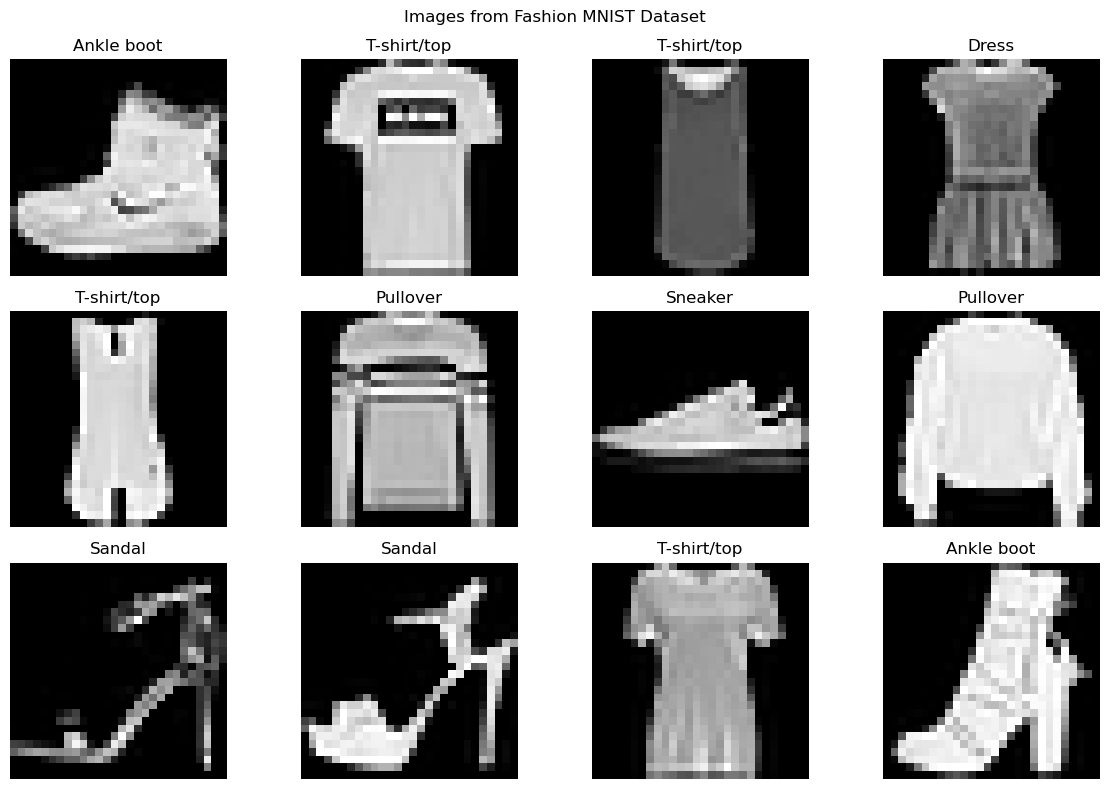

In [3]:
import matplotlib.pyplot as plt
# Verify the data looks as expected
plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f'{class_names[y_train[i]]}')
    plt.axis('off')
plt.suptitle('Images from Fashion MNIST Dataset')
plt.tight_layout()
plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**
# The image quality is good , the features are distinguishable for each category . Each image is 28*28 pixels in gray scale.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [4]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(150, activation='relu'))  # First hidden layer
model.add(Dense(64, activation='relu'))   # Second hidden layer
model.add(Dense(10, activation='softmax'))

# You can use `model.add(<layer>)` to add layers to the model

# Compile the model using `model.compile()`
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train the model with `model.fit()`
history = model.fit(
    X_train, y_train_categorical,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model with `model.evaluate()`
baseline_loss, baseline_accuracy = model.evaluate(X_test, y_test_categorical, verbose=0)
print(f"\n Model Performance:")
print(f"Test Accuracy: {baseline_accuracy:.4f}")
print(f"Test Loss: {baseline_loss:.4f}")


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 150)               117750    
                                                                 
 dense_1 (Dense)             (None, 64)                9664      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 128,064
Trainable params: 128,064
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
375/375 [==============================] - 2s 5ms/step - loss: 0.5653 - accuracy: 0.8024 - val_loss: 0.4513 - val_accuracy: 0.8399
Epoch 2/10
375/375 [====================

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

# I got an accuracy score of 88% , which is quite good for a simple linear classification with just 2 layers . 
# I tried different EPOCS and adding more layers and density but it did not improve the model performance significantly .
# Also this model does not capture spatial relationships in the images.


# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [5]:
from keras.layers import Conv2D, MaxPooling2D,Dropout


# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


# Create a simple CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1))),
model.add(MaxPooling2D((2, 2))),
model.add(Conv2D(64, (3, 3), activation='relu')),
model.add(MaxPooling2D((2, 2))),
model.add(Flatten()),
model.add(Dense(150, activation='relu')),
model.add(Dense(64, activation='relu'))  # Second hidden layer
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# Train the model
history = model.fit(
    X_train, y_train_categorical,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)


# Evaluate the model
cnn_test_loss, cnn_test_accuracy = model.evaluate(
    X_test, y_test_categorical, verbose=0
)

print(f"\nCNN Model Results:")
print(f"Test Loss: {cnn_test_loss:.4f}")
print(f"Test Accuracy: {cnn_test_accuracy:.4f}")


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 1600)              0         
                                                                 
 dense_3 (Dense)             (None, 150)              

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

# Yes the CNN model improved the performance by about 4% , from 88 to 90% . 
# This stems from CNN's ability to capture spatial hierarchies through convolutional layers.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [10]:
filter_results = []
filter_values = [16, 32, 64]

for num_filters in filter_values:
    print(f"\nTesting with {num_filters} filters...")
    
    # Create model with different number of filters
    model = Sequential([
        Conv2D(num_filters, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(num_filters*2, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(150, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Train model
    history = model.fit(
        X_train, y_train_categorical,
        epochs=15,  
        batch_size=128,
        validation_split=0.2,
        verbose=0
    )
    
    # Evaluate model
    test_loss, test_accuracy = model.evaluate(X_test, y_test_categorical, verbose=0)
    
    filter_results.append({
        'filters': num_filters,
        'test_accuracy': test_accuracy,
        'test_loss': test_loss
    })
    
    print(f"Filters: {num_filters}, Test Accuracy: {test_accuracy:.4f}")


Testing with 16 filters...
Filters: 16, Test Accuracy: 0.9015

Testing with 32 filters...
Filters: 32, Test Accuracy: 0.9056

Testing with 64 filters...
Filters: 64, Test Accuracy: 0.9092


In [11]:
dropout_results = []
dropout_values = [0.0, 0.3, 0.5]  # 0.0 means no dropout

for dropout_rate in dropout_values:
    print(f"\nTesting with dropout rate: {dropout_rate}...")
    
    # Create model with/without dropout
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(150, activation='relu'),
        Dense(64, activation='relu'),
        Dropout(dropout_rate) if dropout_rate > 0 else Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Train model
    history = model.fit(
        X_train, y_train_categorical,
        epochs=15,
        batch_size=128,
        validation_split=0.2,
        verbose=0
    )
    
    # Evaluate model
    test_loss, test_accuracy = model.evaluate(X_test, y_test_categorical, verbose=0)
    
    dropout_results.append({
        'dropout_rate': dropout_rate,
        'test_accuracy': test_accuracy,
        'test_loss': test_loss
    })
    
    print(f"Dropout: {dropout_rate}, Test Accuracy: {test_accuracy:.4f}")



Testing with dropout rate: 0.0...
Dropout: 0.0, Test Accuracy: 0.9048

Testing with dropout rate: 0.3...
Dropout: 0.3, Test Accuracy: 0.9073

Testing with dropout rate: 0.5...
Dropout: 0.5, Test Accuracy: 0.9081


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [ ]:
# Use best hyperparameters from experiments
best_filters = [64]  # best filters from previous results
best_dropout = best_dropout_configdropout_results = [0.3]
dropout_values = [0.0, 0.3]  

for dropout_rate in dropout_values:
    print(f"\nTesting with dropout rate: {dropout_rate}...")
    
    # Create model with/without dropout
final_model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64*4, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(150, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(dropout_values),
    Dense(10, activation='softmax')
])
    
final_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )
    
    # Train model
history = model.fit(
        X_train, y_train_categorical,
        epochs=15,
        batch_size=128,
        validation_split=0.2,
        verbose=0
    )
    
    # Evaluate model
test_loss, final_test_accuracy = model.evaluate(X_test, y_test_categorical, verbose=0)
    
dropout_results.append({
        'dropout_rate': dropout_rate,
        'test_accuracy': final_test_accuracy,
        'test_loss': test_loss
    })
    
print(f"Dropout: {dropout_rate}, Test Accuracy: {final_test_accuracy:.4f}")


Testing with dropout rate: 0.0...

Testing with dropout rate: 0.3...
Dropout: 0.3, Test Accuracy: 0.9120


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?
# yes the model performance improved marginally and not what I would have like to see . 

In [ ]:
# Evaluate final model
final_loss, final_accuracy = final_model.evaluate(X_test, y_test_categorical, verbose=0)

print(f"\nFinal Model Performance:")
print(f"Test Accuracy: {final_accuracy:.4f}")
print(f"Test Loss: {final_loss:.4f}")

# Compare all models


print(f"Baseline Model:     {baseline_accuracy:.4f} ({baseline_accuracy:.1%})")
print(f"Simple CNN Model:   {test_accuracy:.4f} ({test_accuracy:.1%})")
print(f"Final Model:        {final_test_accuracy:.4f} ({final_test_accuracy:.1%})")




Final Model Performance:
Test Accuracy: 0.1000
Test Loss: 2.2988
Baseline Model:     0.8846 (88.5%)
Simple CNN Model:   0.9100 (91.0%)
Final Model:        0.9120 (91.2%)


# compared to the baseline model , both the CNN and the final model perform better . I am not too happy with the 91.2% score . I would may be add more depth and layers and rate scheduling and momentum to accelarate the learning . Also I feel the model is memorizing at this point instead of learning (overfitting) , as seen with the marginal difference between each epocs. Would love for the LS comments on what best I could have done to enhance the learning further . 

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 06/07/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-ml-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.